# PINN 2D Heat Transfer — Combustion Chamber Wall

**Mots-clés** : cryogenic engine thermomechanics, propulsion thermique, Physics-Informed Neural Networks

## Contexte physique

On modélise le transfert thermique transitoire dans une paroi de chambre de combustion cryogénique.
Le domaine 2D représente une coupe de paroi soumise à :

- **Côté gaz chaud (y=e)** : convection de Newton
- **Côté fluide cryogénique (y=0)** : convection
- **Bords latéraux** : adiabatique
- **Conductivité variable** : k(T) = k₀(1 + βT)

### Équation adimensionnelle

θ = (T - T_cold)/(T_hot - T_cold), ξ = x/L, η = y/e, τ = t·k₀/(ρCₚe²)

∂θ/∂τ = (e/L)² ∂/∂ξ(k̃ ∂θ/∂ξ) + ∂/∂η(k̃ ∂θ/∂η)


In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
torch.manual_seed(42)
np.random.seed(42)


Device: cuda


## Paramètres physiques — Alliage CuCr, propulsion cryogénique

In [2]:
L = 0.05; e = 0.005; t_max = 2.0
rho = 8900.0; Cp = 385.0; k0 = 320.0; beta = 1e-4
h_hot = 5000.0; T_hot = 3500.0
h_cold = 15000.0; T_cold = 100.0
T_init = 300.0

DT = T_hot - T_cold
t_ref = rho * Cp * e**2 / k0
tau_max = t_max / t_ref
aspect = (e / L)**2
Bi_hot = h_hot * e / k0
Bi_cold = h_cold * e / k0
theta_init = (T_init - T_cold) / DT

print(f"t_ref = {t_ref:.4f} s, tau_max = {tau_max:.3f}")
print(f"Bi_hot = {Bi_hot:.4f}, Bi_cold = {Bi_cold:.4f}")
print(f"(e/L)^2 = {aspect:.4e}, theta_init = {theta_init:.4f}")


t_ref = 0.2677 s, tau_max = 7.471
Bi_hot = 0.0781, Bi_cold = 0.2344
(e/L)^2 = 1.0000e-02, theta_init = 0.0588


## Architecture du réseau

In [3]:
class PINN2DHeat(nn.Module):
    def __init__(self, layers):
        super().__init__()
        modules = []
        for i in range(len(layers) - 2):
            modules.append(nn.Linear(layers[i], layers[i+1]))
            modules.append(nn.Tanh())
        modules.append(nn.Linear(layers[-2], layers[-1]))
        self.net = nn.Sequential(*modules)
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, xi, eta, tau):
        return self.net(torch.cat([xi, eta, tau], dim=1))

model = PINN2DHeat([3, 64, 64, 64, 64, 1]).to(device)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")


Parameters: 12,801


## Résidus PDE et conditions aux limites (adimensionnels)

In [4]:
def k_tilde(theta):
    return 1.0 + beta * (theta * DT + T_cold)

def pde_residual(model, xi, eta, tau):
    xi = xi.requires_grad_(True)
    eta = eta.requires_grad_(True)
    tau = tau.requires_grad_(True)
    theta = model(xi, eta, tau)
    kt = k_tilde(theta)

    d = torch.autograd.grad(theta.sum(), [xi, eta, tau], create_graph=True)
    theta_xi, theta_eta, theta_tau = d

    flux_xi = kt * theta_xi
    flux_eta = kt * theta_eta
    d_flux_xi = torch.autograd.grad(flux_xi.sum(), xi, create_graph=True)[0]
    d_flux_eta = torch.autograd.grad(flux_eta.sum(), eta, create_graph=True)[0]

    return theta_tau - aspect * d_flux_xi - d_flux_eta

def sample_data(n_int, n_bc, n_ic):
    pts = {}
    pts["int"] = (torch.rand(n_int,1,device=device), torch.rand(n_int,1,device=device),
                  torch.rand(n_int,1,device=device)*tau_max)
    pts["hot"] = (torch.rand(n_bc,1,device=device), torch.ones(n_bc,1,device=device),
                  torch.rand(n_bc,1,device=device)*tau_max)
    pts["cold"] = (torch.rand(n_bc,1,device=device), torch.zeros(n_bc,1,device=device),
                   torch.rand(n_bc,1,device=device)*tau_max)
    pts["left"] = (torch.zeros(n_bc,1,device=device), torch.rand(n_bc,1,device=device),
                   torch.rand(n_bc,1,device=device)*tau_max)
    pts["right"] = (torch.ones(n_bc,1,device=device), torch.rand(n_bc,1,device=device),
                    torch.rand(n_bc,1,device=device)*tau_max)
    pts["ic"] = (torch.rand(n_ic,1,device=device), torch.rand(n_ic,1,device=device),
                 torch.zeros(n_ic,1,device=device))
    return pts

def loss_fn(model, pts):
    res = pde_residual(model, *pts["int"])
    loss_pde = (res**2).mean()

    # BC hot (eta=1): -k_tilde * dtheta/deta = Bi_hot * (theta - 1)
    xi_h, eta_h, tau_h = pts["hot"]
    xi_h = xi_h.requires_grad_(True); eta_h = eta_h.requires_grad_(True); tau_h = tau_h.requires_grad_(True)
    th_h = model(xi_h, eta_h, tau_h)
    dth_h = torch.autograd.grad(th_h.sum(), eta_h, create_graph=True)[0]
    loss_hot = ((-k_tilde(th_h)*dth_h - Bi_hot*(th_h - 1.0))**2).mean()

    # BC cold (eta=0): k_tilde * dtheta/deta = Bi_cold * theta
    xi_c, eta_c, tau_c = pts["cold"]
    xi_c = xi_c.requires_grad_(True); eta_c = eta_c.requires_grad_(True); tau_c = tau_c.requires_grad_(True)
    th_c = model(xi_c, eta_c, tau_c)
    dth_c = torch.autograd.grad(th_c.sum(), eta_c, create_graph=True)[0]
    loss_cold = ((k_tilde(th_c)*dth_c - Bi_cold*th_c)**2).mean()

    # Adiabatic: dtheta/dxi = 0
    loss_adi = torch.tensor(0.0, device=device)
    for key in ["left", "right"]:
        xi_a, eta_a, tau_a = pts[key]
        xi_a = xi_a.requires_grad_(True); eta_a = eta_a.requires_grad_(True); tau_a = tau_a.requires_grad_(True)
        th_a = model(xi_a, eta_a, tau_a)
        dth_a = torch.autograd.grad(th_a.sum(), xi_a, create_graph=True)[0]
        loss_adi = loss_adi + (dth_a**2).mean()

    # IC: theta(xi, eta, 0) = theta_init
    loss_ic = ((model(*pts["ic"]) - theta_init)**2).mean()

    total = loss_pde + 10.0*(loss_hot + loss_cold + loss_adi) + 50.0*loss_ic
    return total, {"pde": loss_pde.item(), "bc_hot": loss_hot.item(),
                   "bc_cold": loss_cold.item(), "ic": loss_ic.item()}


## Entraînement

In [5]:
N_EPOCHS = 8000

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS, eta_min=1e-5)

history = {"total": [], "pde": [], "bc_hot": [], "bc_cold": [], "ic": []}

for epoch in range(1, N_EPOCHS + 1):
    pts = sample_data(4000, 500, 1000)
    optimizer.zero_grad()
    loss, comp = loss_fn(model, pts)
    loss.backward()
    optimizer.step()
    scheduler.step()

    history["total"].append(loss.item())
    for k in ["pde", "bc_hot", "bc_cold", "ic"]:
        history[k].append(comp[k])

    if epoch % 1000 == 0 or epoch == 1:
        print(f"Epoch {epoch:5d} | Loss: {loss.item():.4e} | "
              f"PDE: {comp['pde']:.3e} | BC_hot: {comp['bc_hot']:.3e} | "
              f"BC_cold: {comp['bc_cold']:.3e} | IC: {comp['ic']:.3e}")


Epoch     1 | Loss: 6.5947e+00 | PDE: 5.399e-03 | BC_hot: 2.511e-02 | BC_cold: 6.760e-02 | IC: 4.947e-02
Epoch  1000 | Loss: 8.8786e-04 | PDE: 8.431e-05 | BC_hot: 3.462e-05 | BC_cold: 1.393e-05 | IC: 6.119e-06
Epoch  2000 | Loss: 4.6716e-04 | PDE: 3.427e-05 | BC_hot: 1.922e-05 | BC_cold: 6.417e-06 | IC: 3.252e-06
Epoch  3000 | Loss: 2.5636e-04 | PDE: 4.092e-05 | BC_hot: 8.786e-06 | BC_cold: 1.194e-06 | IC: 2.182e-06
Epoch  4000 | Loss: 2.0350e-04 | PDE: 2.109e-05 | BC_hot: 4.893e-06 | BC_cold: 9.505e-07 | IC: 2.357e-06
Epoch  5000 | Loss: 1.9850e-04 | PDE: 1.446e-05 | BC_hot: 7.996e-06 | BC_cold: 6.230e-07 | IC: 1.854e-06
Epoch  6000 | Loss: 2.0533e-04 | PDE: 1.203e-05 | BC_hot: 1.004e-05 | BC_cold: 4.713e-07 | IC: 1.706e-06
Epoch  7000 | Loss: 1.2948e-04 | PDE: 1.205e-05 | BC_hot: 3.930e-06 | BC_cold: 2.857e-07 | IC: 1.437e-06
Epoch  8000 | Loss: 1.2245e-04 | PDE: 1.649e-05 | BC_hot: 3.246e-06 | BC_cold: 2.750e-07 | IC: 1.361e-06


## Courbes de convergence

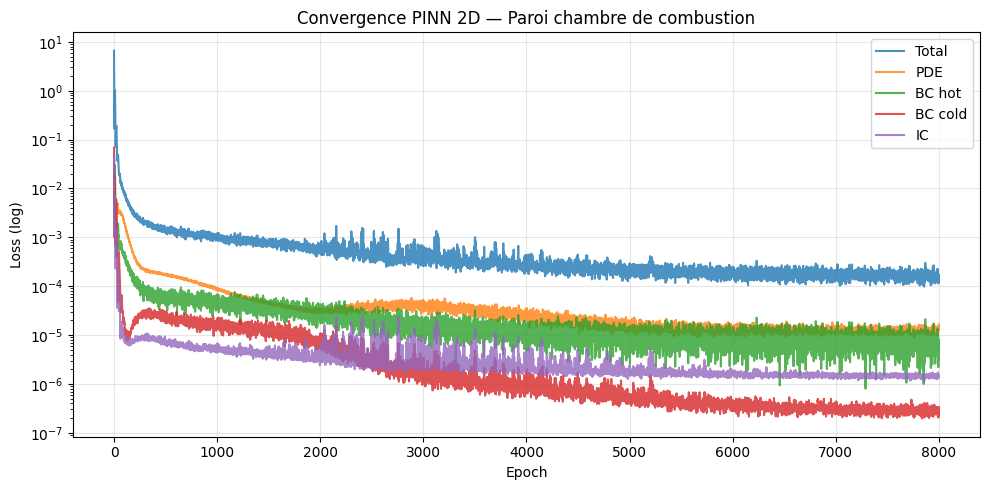

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
for k, label in [("total","Total"),("pde","PDE"),("bc_hot","BC hot"),("bc_cold","BC cold"),("ic","IC")]:
    ax.semilogy(history[k], label=label, alpha=0.8)
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss (log)")
ax.set_title("Convergence PINN 2D — Paroi chambre de combustion")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("convergence_pinn2d.png", dpi=150, bbox_inches="tight")
plt.show()


## Champ de température

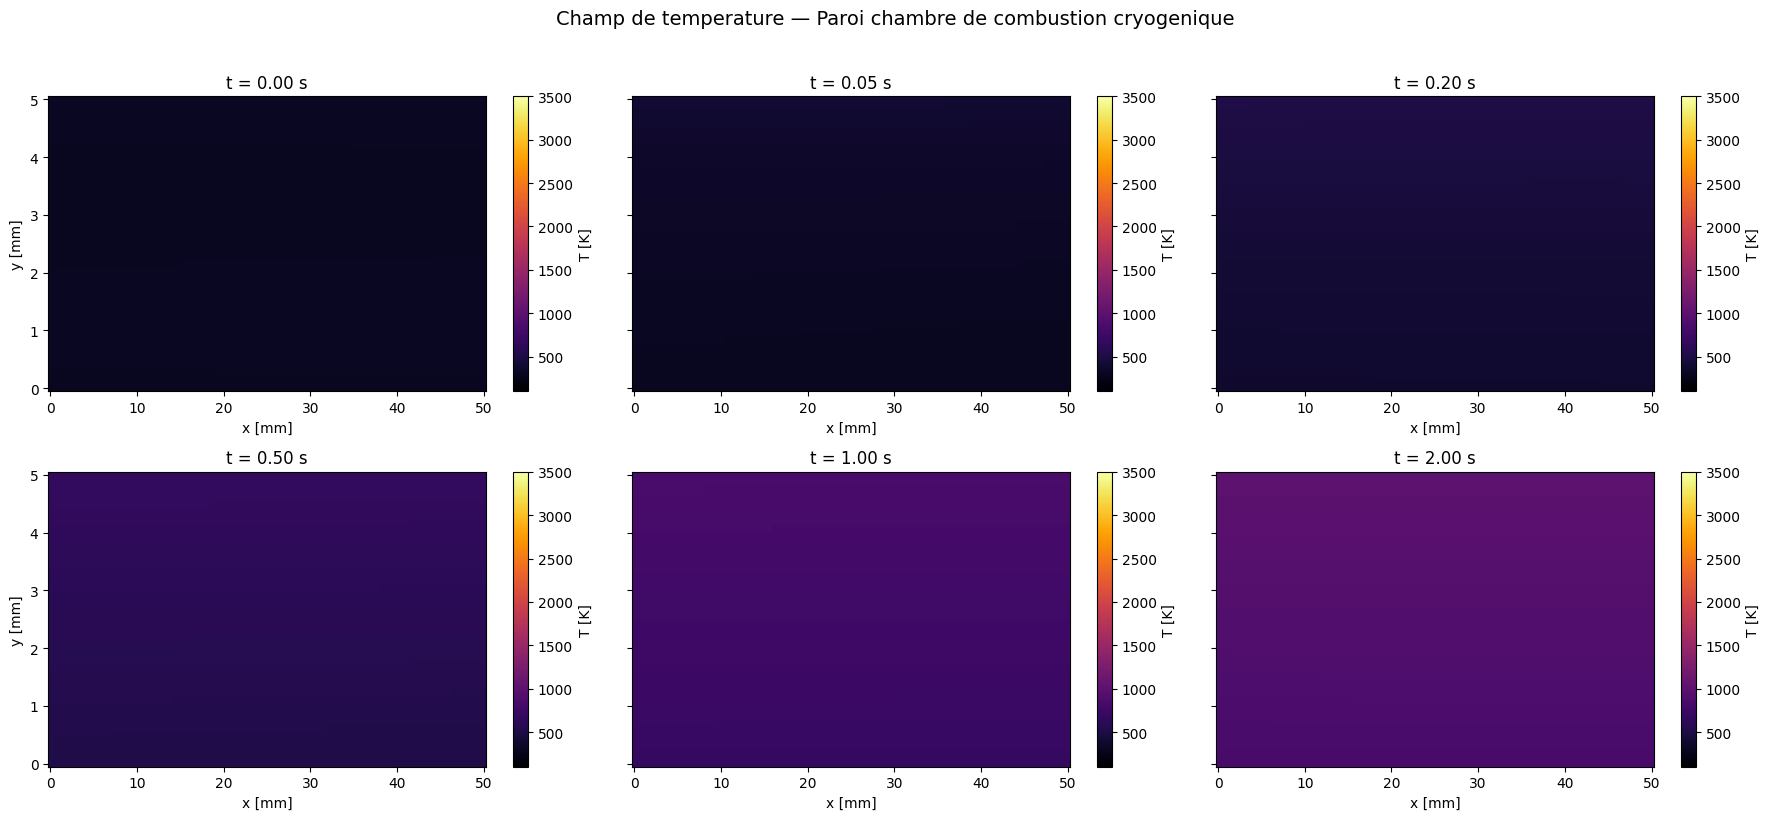

In [7]:
@torch.no_grad()
def predict_field(model, t_val, nx=100, ny=50):
    xi = np.linspace(0, 1, nx); eta = np.linspace(0, 1, ny)
    XI, ETA = np.meshgrid(xi, eta)
    xi_t = torch.tensor(XI.flatten(), dtype=torch.float32).unsqueeze(1).to(device)
    eta_t = torch.tensor(ETA.flatten(), dtype=torch.float32).unsqueeze(1).to(device)
    tau_t = torch.full_like(xi_t, t_val / t_ref).to(device)
    theta = model(xi_t, eta_t, tau_t).cpu().numpy().reshape(ny, nx)
    return XI * L * 1000, ETA * e * 1000, theta * DT + T_cold

times = [0.0, 0.05, 0.2, 0.5, 1.0, 2.0]
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharey=True)
for ax, t_val in zip(axes.flatten(), times):
    X_mm, Y_mm, T = predict_field(model, t_val)
    pcm = ax.pcolormesh(X_mm, Y_mm, T, cmap="inferno", shading="auto", vmin=T_cold, vmax=T_hot)
    ax.set_title(f"t = {t_val:.2f} s"); ax.set_xlabel("x [mm]")
    plt.colorbar(pcm, ax=ax, label="T [K]")
axes[0,0].set_ylabel("y [mm]"); axes[1,0].set_ylabel("y [mm]")
fig.suptitle("Champ de temperature — Paroi chambre de combustion cryogenique", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("temperature_field_2d.png", dpi=150, bbox_inches="tight")
plt.show()


## Profil de température dans l'épaisseur

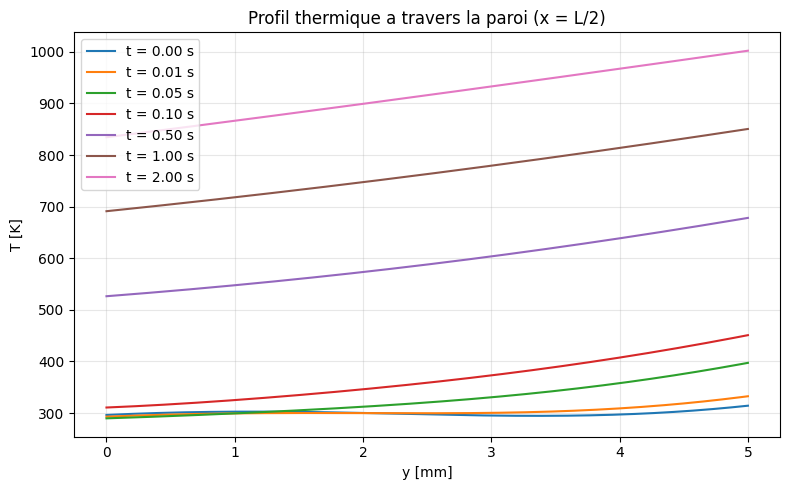

In [8]:
@torch.no_grad()
def profile_thickness(model, t_val, ny=200):
    eta = np.linspace(0, 1, ny)
    xi_t = torch.full((ny,1), 0.5, dtype=torch.float32).to(device)
    eta_t = torch.tensor(eta, dtype=torch.float32).unsqueeze(1).to(device)
    tau_t = torch.full((ny,1), t_val/t_ref, dtype=torch.float32).to(device)
    theta = model(xi_t, eta_t, tau_t).cpu().numpy().flatten()
    return eta * e * 1000, theta * DT + T_cold

fig, ax = plt.subplots(figsize=(8, 5))
for t_val in [0.0, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0]:
    y_mm, T = profile_thickness(model, t_val)
    ax.plot(y_mm, T, label=f"t = {t_val:.2f} s")
ax.set_xlabel("y [mm]"); ax.set_ylabel("T [K]")
ax.set_title("Profil thermique a travers la paroi (x = L/2)")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("thickness_profile.png", dpi=150, bbox_inches="tight")
plt.show()


## Conductivité variable k(T)

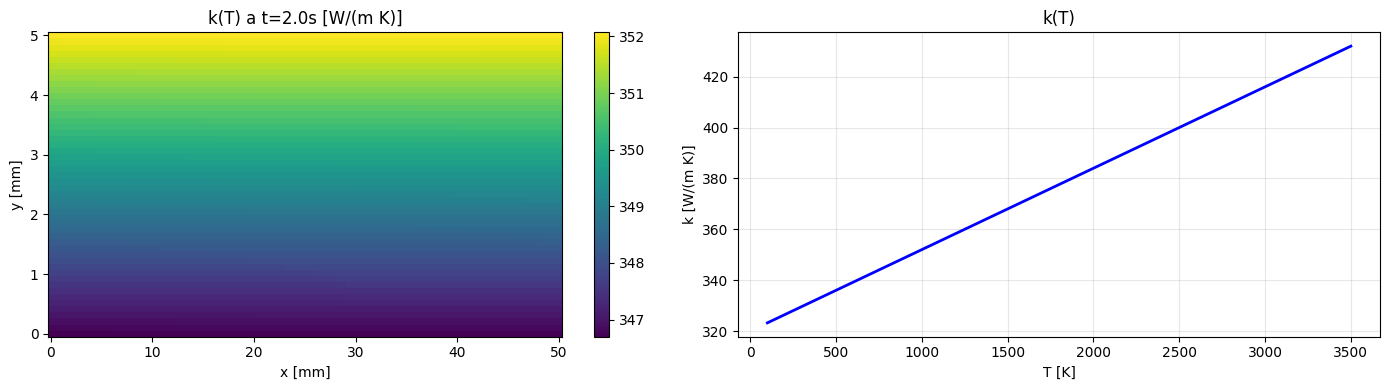

In [9]:
@torch.no_grad()
def conductivity_field(model, t_val, nx=100, ny=50):
    xi = np.linspace(0,1,nx); eta = np.linspace(0,1,ny)
    XI, ETA = np.meshgrid(xi, eta)
    xi_t = torch.tensor(XI.flatten(), dtype=torch.float32).unsqueeze(1).to(device)
    eta_t = torch.tensor(ETA.flatten(), dtype=torch.float32).unsqueeze(1).to(device)
    tau_t = torch.full_like(xi_t, t_val/t_ref).to(device)
    theta = model(xi_t, eta_t, tau_t).cpu().numpy().reshape(ny, nx)
    T_f = theta * DT + T_cold
    return XI*L*1000, ETA*e*1000, k0*(1+beta*T_f)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
X_mm, Y_mm, k_f = conductivity_field(model, 2.0)
pcm = ax1.pcolormesh(X_mm, Y_mm, k_f, cmap="viridis", shading="auto")
ax1.set_title("k(T) a t=2.0s [W/(m K)]"); ax1.set_xlabel("x [mm]"); ax1.set_ylabel("y [mm]")
plt.colorbar(pcm, ax=ax1)

T_r = np.linspace(T_cold, T_hot, 200)
ax2.plot(T_r, k0*(1+beta*T_r), "b-", lw=2)
ax2.set_xlabel("T [K]"); ax2.set_ylabel("k [W/(m K)]"); ax2.set_title("k(T)")
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("conductivity_variable.png", dpi=150, bbox_inches="tight")
plt.show()


## Conclusions

Ce PINN 2D résout le transfert thermique transitoire dans une paroi de chambre de combustion cryogénique :

- **Convection de Newton** sur les deux faces (gaz chaud / fluide cryogénique)
- **Conductivité variable** k(T) = k₀(1 + βT)
- **Gradient extrême** : 100 K → 3500 K
- **Formulation adimensionnelle** pour stabilité numérique

### Extensions
- Couplage thermomécanique, propriétés non-linéaires Cp(T), canaux de refroidissement régénératifs

---
*Domaine : **propulsion thermique**, **cryogenic engine thermomechanics***
